# Exploratory Data Analysis

Aqui pretendo explicitar todos os achados na parte de engenharia de dados que apoiam as decisões tomadas para realizar a calibração e teste adequado dos modelos. 

In [63]:
from pathlib import Path
import numpy as np
import os

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists()
)


In [ ]:
import pandas as pd

path_calendar = PROJECT_ROOT / "data/calendars/03_refined/Calendar_BR_dim.parquet"
path_fwd = PROJECT_ROOT / "data/03_refined/b3/forwards/b3_forwards_di1_refined.parquet"
path_swp = PROJECT_ROOT / "data/03_refined/b3/swaps/b3_swaps_dipre_refined.parquet"
path_bnd = PROJECT_ROOT / "data/04_feature/curve_factory/public_bonds/mart_public_bonds_curve_inputs_dimension_batch.parquet"

df_calendar = pd.read_parquet(path_calendar)
df_fwds_DI = pd.read_parquet(path_fwd)
df_swps_DI = pd.read_parquet(path_swp)
df_candidates = pd.read_parquet(path_bnd)

df_calendar["date"] = pd.to_datetime(
    df_calendar["date"], utc=True
).dt.tz_convert(None).dt.normalize()

df_candidates["date"] = pd.to_datetime(
    df_candidates["ref_date"], utc=True
).dt.tz_convert(None).dt.normalize()

df_fwds_DI["date"] = pd.to_datetime(
    df_fwds_DI["date"], utc=True
).dt.tz_convert(None).dt.normalize()

df_swps_DI["date"] = pd.to_datetime(
    df_swps_DI["date"], utc=True
).dt.tz_convert(None).dt.normalize()

data_maxima = df_candidates["date"].max()

df_calendar_filtrado = df_calendar.loc[
    df_calendar["date"] <= data_maxima
].copy()

business_days = df_calendar_filtrado[df_calendar_filtrado["is_business_day"] == 1].copy()
df_calendar_filtrado.head()

## 1. Estrutura, disponibilidade e cobertura dos datasets
Antes de iniciar a construção das curvas, é necessário compreender não apenas o tamanho de cada base, mas também o que cada observação representa, sua regularidade temporal e a distribuição dos vencimentos disponíveis. O número total de linhas, isoladamente, não determina a qualidade de um dataset para estimação: uma base pode ser extensa por cobrir muitos anos, por possuir muitos vértices em cada data ou por uma combinação desses dois fatores. Portanto, esta análise separa três dimensões: extensão histórica, continuidade diária e densidade transversal da curva.

In [71]:
print(f"""
df_swps_DIxPre shape: {df_swps_DI.shape}
df_fwds_DI shape    : {df_fwds_DI.shape}
df_bonds shape      : {df_candidates.shape}""")


df_swps_DIxPre shape: (412297, 13)
df_fwds_DI shape    : (58474, 15)
df_bonds shape      : (69419, 25)


### Dimensão e natureza das bases
Os datasets apresentam diferenças significativas de tamanho. Na versão atualmente carregada no notebook, a base de futuros de DI possui aproximadamente 58 mil registros, a base de títulos públicos cerca de 69 mil e a base de swaps DI×Pré mais de 412 mil. Assim, em número total de linhas, os futuros constituem a menor base, seguidos pelos títulos públicos e, com ampla diferença, pelos swaps.

Esse resultado não deve ser interpretado apenas como uma diferença de disponibilidade. O tamanho de cada base decorre também da natureza de seu mercado. Os dados de títulos públicos representam um universo relativamente limitado de instrumentos em circulação. Os futuros dependem dos contratos listados e das informações efetivamente disponíveis para cada pregão. Já a base de swaps contém taxas de referência divulgadas pela B3 para uma grade extensa de vencimentos, o que produz um número significativamente maior de observações por data.

A inspeção por meio de .info() permite verificar, adicionalmente, a estrutura das variáveis, seus tipos e a presença de valores ausentes. Essa etapa é especialmente importante porque as três bases não utilizam necessariamente a mesma representação para datas, taxas, preços e vencimentos. Antes de qualquer comparação ou estimação, essas variáveis deverão ser harmonizadas, com destaque para a adoção do bd_to_maturity como medida comum de tenor.

In [14]:
print(f"df_fwds_DI shape: {df_fwds_DI.info()}")
df_fwds_DI.head()

<class 'pandas.DataFrame'>
RangeIndex: 58474 entries, 0 to 58473
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              58474 non-null  datetime64[us]
 1   asset             58474 non-null  str           
 2   ticker            58474 non-null  str           
 3   adjusted_price    58473 non-null  float64       
 4   adjusted_pu       58473 non-null  float64       
 5   maturity          58474 non-null  datetime64[us]
 6   days_to_maturity  58474 non-null  int64         
 7   bd_to_maturity    58474 non-null  int64         
 8   bid_price         39606 non-null  float64       
 9   ask_price         39215 non-null  float64       
 10  close_price       52046 non-null  float64       
 11  average_price     52046 non-null  float64       
 12  minimum_price     52046 non-null  float64       
 13  maximum_price     52046 non-null  float64       
 14  quantity          52046 non-null 

,date,asset,ticker,adjusted_price,adjusted_pu,maturity,days_to_maturity,bd_to_maturity,bid_price,ask_price,close_price,average_price,minimum_price,maximum_price,quantity
0,2020-01-01,DI1,DI1F20,4.400,100000.00,2020-01-01,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-01,DI1,DI1G20,4.412,99623.79,2020-02-02,32,22,4.409,4.410,4.410,4.410,4.409,4.422,48.0
2,2020-01-01,DI1,DI1H20,4.375,99322.62,2020-03-01,60,40,4.365,4.375,4.375,4.378,4.370,4.380,6.0
3,2020-01-01,DI1,DI1J20,4.336,98961.12,2020-03-31,90,62,4.338,4.340,4.336,4.335,4.320,4.338,93.0
4,2020-01-01,DI1,DI1K20,4.310,98636.31,2020-05-03,123,82,4.300,4.350,4.310,4.312,4.305,4.350,8.0


In [15]:
print(f"df_swps_DI shape: {df_swps_DI.info()}")
df_swps_DI.head()

<class 'pandas.DataFrame'>
RangeIndex: 412297 entries, 0 to 412296
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   date              412297 non-null  datetime64[us]
 1   product_code      412297 non-null  str           
 2   name              412297 non-null  str           
 3   underlying        412297 non-null  str           
 4   adjusted_value    412297 non-null  float64       
 5   maturity          412297 non-null  datetime64[us]
 6   days_to_maturity  412297 non-null  int64         
 7   bd_to_maturity    412297 non-null  int64         
 8   days_to_delivery  412297 non-null  int64         
 9   fixed_leg         412297 non-null  str           
 10  float_leg         412297 non-null  str           
 11  quote_type        412297 non-null  str           
 12  lineage_id        412297 non-null  str           
dtypes: datetime64[us](2), float64(1), int64(3), str(7)
memory usage: 75.9 

,date,product_code,name,underlying,adjusted_value,maturity,days_to_maturity,bd_to_maturity,days_to_delivery,fixed_leg,float_leg,quote_type,lineage_id
0,2020-01-02,T1PRE,DIxPRE,DI x PRE,4.400,2020-01-03,1,1,1,PRE,DI,F,a39dbcbc05ec4adee7295f74ced20d6e50db75a948de8a...
1,2020-01-02,T1PRE,DIxPRE,DI x PRE,4.410,2020-01-09,7,5,7,PRE,DI,F,a39dbcbc05ec4adee7295f74ced20d6e50db75a948de8a...
2,2020-01-02,T1PRE,DIxPRE,DI x PRE,4.411,2020-01-15,13,9,13,PRE,DI,M,a39dbcbc05ec4adee7295f74ced20d6e50db75a948de8a...
3,2020-01-02,T1PRE,DIxPRE,DI x PRE,4.411,2020-01-16,14,10,14,PRE,DI,F,a39dbcbc05ec4adee7295f74ced20d6e50db75a948de8a...
4,2020-01-02,T1PRE,DIxPRE,DI x PRE,4.412,2020-01-20,18,12,18,PRE,DI,M,a39dbcbc05ec4adee7295f74ced20d6e50db75a948de8a...


In [52]:
df_candidates = df_candidates.rename(columns={ "maturity_date": "maturity"})
print(f"df_candidates shape: {df_candidates.info()}")
df_candidates.head()

<class 'pandas.DataFrame'>
RangeIndex: 69419 entries, 0 to 69418
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype        
---  ------                    --------------  -----        
 0   ref_date                  69419 non-null  object       
 1   instrument_type           69419 non-null  str          
 2   isin                      69419 non-null  str          
 3   issue_date                69419 non-null  object       
 4   maturity                  69419 non-null  object       
 5   bd_to_maturity            69419 non-null  int64        
 6   market_pu                 69419 non-null  float64      
 7   market_ytm                69419 non-null  float64      
 8   macaulay_duration         69419 non-null  float64      
 9   modified_duration         69419 non-null  float64      
 10  numero_observacoes_dia    69419 non-null  int64        
 11  numero_observacoes_curto  69419 non-null  float64      
 12  numero_observacoes_medio  69419 non-null  f

,ref_date,instrument_type,isin,issue_date,maturity,bd_to_maturity,market_pu,market_ytm,macaulay_duration,modified_duration,...,flag_cobertura_tenors,flag_ocupacao_tenors,quote_quality,quote_source,primary_quote_type,market_pu_source,market_ytm_source,solver_method,solver_iterations,date
0,2007-01-02,LTN,BRSTNCLTN616,2005-09-28,2007-04-01,61,970.717343,0.128396,0.246032,0.218037,...,GOOD,MEDIUM,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0,2007-01-02
1,2007-01-02,LTN,BRSTNCLTN5Z0,2005-06-01,2007-07-01,123,943.260185,0.126044,0.492063,0.436984,...,GOOD,MEDIUM,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0,2007-01-02
2,2007-01-02,LTN,BRSTNCLTN632,2006-02-13,2007-10-01,188,916.025352,0.124761,0.746032,0.663280,...,GOOD,MEDIUM,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0,2007-01-02
3,2007-01-02,LTN,BRSTNCLTN608,2005-07-22,2008-01-01,249,890.316632,0.124240,0.992063,0.882430,...,GOOD,MEDIUM,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0,2007-01-02
4,2007-01-02,LTN,BRSTNCLTN657,2006-08-04,2008-04-01,311,865.471089,0.124200,1.234127,1.097782,...,GOOD,MEDIUM,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0,2007-01-02


Importante destacar que os dados de título publico negociados em mercado secundário diponibilizados na base da DEMAB possuíam em sua grande maioria apenas o PU média sendo os dados de YTM reconstruídos a partir disso

## 2. Cobertura histórica e continuidade diária
A comparação com o calendário de dias úteis revela uma distinção importante entre tamanho e cobertura histórica. Embora a base de títulos públicos não seja a mais densa transversalmente, ela possui a série temporal mais longa: os dados estão disponíveis desde 2007 e cobrem praticamente todos os dias úteis do período.

As bases da B3 utilizadas neste estudo começam apenas em 2020. Entre elas, os swaps DI×Pré apresentam maior regularidade, com poucas lacunas internas. Os futuros de DI, por outro lado, possuem diversos dias úteis sem observações. Essa diferença terá consequências para o desenho experimental. A série de títulos públicos permite utilizar o período anterior a 2020 para desenvolvimento, análise de estabilidade e calibração inicial. Entretanto, qualquer comparação entre os três mercados deverá ser conduzida apenas no período comum — e, idealmente, nas datas presentes simultaneamente nas três bases. Isso evita atribuir aos modelos diferenças que, na realidade, decorreriam de períodos econômicos ou regimes de mercado distintos.

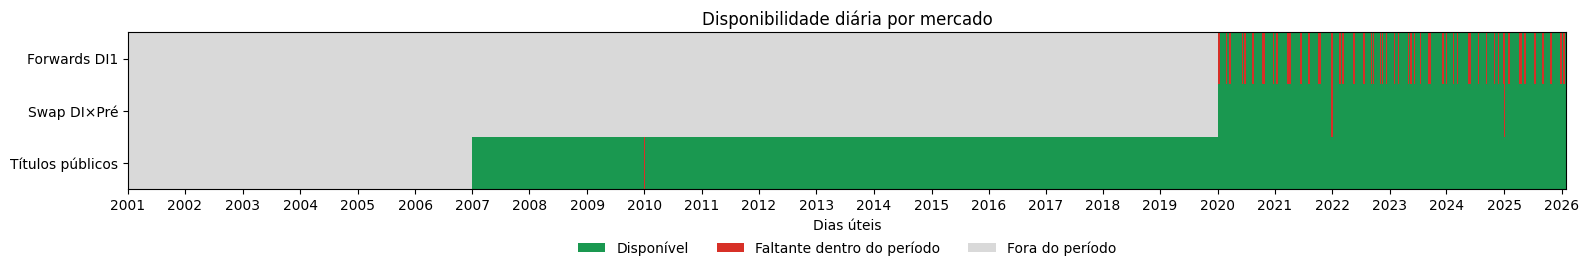

In [51]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


def plotar_disponibilidade_mercados(
    calendario,
    forwards,
    swaps,
    bonds,
    calendar_date_col="date",
    ref_date_col="date",
):

    def normalizar_datas(serie):
        # Converte datas timezone-aware e naive para o mesmo padrão diário.
        return pd.to_datetime(serie, errors="coerce", utc=True).dt.tz_convert(None).dt.normalize()

    dias_uteis = (
        calendario.loc[calendario["is_business_day"], [calendar_date_col]]
        .rename(columns={calendar_date_col: "date"})
        .assign(date=lambda df: normalizar_datas(df["date"]))
        .drop_duplicates()
        .sort_values("date")
        .reset_index(drop=True)
    )

    mercados = {
        "Forwards DI1": forwards,
        "Swap DI×Pré": swaps,
        "Títulos públicos": bonds,
    }

    disponibilidade = dias_uteis.copy()

    for nome, df in mercados.items():
        datas_disponiveis = normalizar_datas(df[ref_date_col]).dropna().drop_duplicates()
        inicio, fim = datas_disponiveis.min(), datas_disponiveis.max()

        # -1: fora do período; 0: buraco; 1: observação disponível.
        status = pd.Series(-1, index=disponibilidade.index, dtype="int8")
        dentro_periodo = disponibilidade["date"].between(inicio, fim)
        status.loc[dentro_periodo] = 0
        status.loc[disponibilidade["date"].isin(datas_disponiveis)] = 1
        disponibilidade[nome] = status

    matriz = (
        disponibilidade
        .set_index("date")
        .T
        .astype(int)
    )

    fig, ax = plt.subplots(figsize=(16, 3))

    ax.imshow(
        matriz,
        aspect="auto",
        interpolation="nearest",
        cmap=ListedColormap(["#d9d9d9", "#d73027", "#1a9850"]),
        vmin=-1,
        vmax=1,
    )

    ax.set_yticks(range(len(matriz.index)), labels=matriz.index)

    ticks = disponibilidade.groupby(disponibilidade["date"].dt.year).head(1).index
    ax.set_xticks(
        ticks,
        labels=[matriz.columns[i].strftime("%Y") for i in ticks],
    )

    ax.set_xlabel("Dias úteis")
    ax.set_title("Disponibilidade diária por mercado")
    ax.grid(False)
    ax.legend(
        handles=[
            Patch(facecolor="#1a9850", label="Disponível"),
            Patch(facecolor="#d73027", label="Faltante dentro do período"),
            Patch(facecolor="#d9d9d9", label="Fora do período"),
        ],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.25),
        ncols=3,
        frameon=False,
    )

    plt.tight_layout()
    return disponibilidade, ax

disponibilidade, ax = plotar_disponibilidade_mercados(
    calendario=df_calendar_filtrado,
    forwards=df_fwds_DI,
    swaps=df_swps_DI,
    bonds=df_candidates,
)

plt.show()

### Quantidade de vencimentos disponíveis

In [60]:
from functools import reduce

mercados = {
    "Forwards": df_fwds_DI,
    "Swaps": df_swps_DI,
    "Bonds": df_candidates,
}

# Padronização
painel = pd.concat(
    [
        df.assign(
            mercado=nome,
            date=pd.to_datetime(df["date"]).dt.normalize(),
            tenor_anos=df["bd_to_maturity"] / 252,
        )[["date", "mercado", "bd_to_maturity", "tenor_anos"]]
        for nome, df in mercados.items()
    ],
    ignore_index=True,
)

# Comparação somente nas datas presentes nos três mercados
datas_comuns = reduce(
    set.intersection,
    [set(pd.to_datetime(df["date"]).dt.normalize()) for df in mercados.values()],
)

painel = painel[painel["date"].isin(datas_comuns)].drop_duplicates(
    ["date", "mercado", "bd_to_maturity"]
)

resumo_diario = (
    painel.groupby(["mercado", "date"])
    .agg(
        quantidade_tenors=("bd_to_maturity", "nunique"),
        tenor_minimo=("tenor_anos", "min"),
        tenor_mediano=("tenor_anos", "median"),
        tenor_maximo=("tenor_anos", "max"),
    )
    .reset_index()
)


Os boxplots evidenciam diferenças relevantes na quantidade de vértices observados diariamente. Os títulos públicos apresentam o menor número de vencimentos distintos por data. Esse resultado é coerente com a própria estrutura do mercado: existe um conjunto limitado de títulos em circulação e os vencimentos são determinados pelas emissões do Tesouro, não por uma grade contínua de prazos.

Os futuros de DI ocupam uma posição intermediária. Embora possuam mais vencimentos diários que os títulos públicos, sua cobertura depende dos contratos listados e disponíveis em cada pregão. Os swaps apresentam, com ampla vantagem, a maior quantidade de vértices, chegando a aproximadamente 300 vencimentos em algumas datas.

Essa maior quantidade se deve ao fato dessa já serem taxas referênciais divulgadas pela Bolsa e não as negociações propriamente ditas.

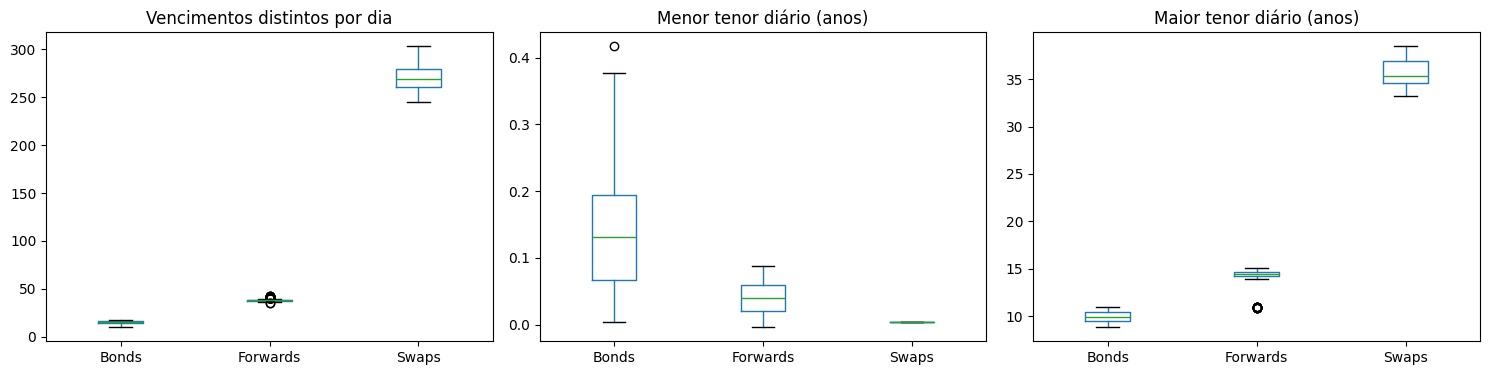

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metricas = {
    "quantidade_tenors": "Vencimentos distintos por dia",
    "tenor_minimo": "Menor tenor diário (anos)",
    "tenor_maximo": "Maior tenor diário (anos)",
}

for ax, (coluna, titulo) in zip(axes, metricas.items()):
    resumo_diario.boxplot(
        column=coluna,
        by="mercado",
        ax=ax,
        grid=False,
    )
    ax.set_title(titulo)
    ax.set_xlabel("")

fig.suptitle("")
plt.tight_layout()

### Amplitude da cobertura de tenors
A análise dos menores e maiores tenors diários reforça a superioridade dos swaps em termos de amplitude. Em média, a base de swaps alcança vencimentos mais curtos e, simultaneamente, vencimentos mais longos. Isso significa que ela cobre de maneira mais completa tanto a região inicial quanto a cauda da curva.

Os títulos públicos apresentam a cobertura mais restrita nos dois extremos. Seu menor tenor diário costuma ser superior ao observado nos outros mercados, indicando menor representação do curtíssimo prazo. Ao mesmo tempo, seu maior tenor diário é, em média, inferior ao dos swaps e futuros, limitando a informação disponível na parte longa da curva.

Esse resultado não deve ser descrito simplesmente como uma “pior qualidade” da base de títulos. Essa característica é diretamente relevante, pois aumenta o risco de instabilidade dos modelos mais flexíveis e torna a extrapolação especialmente sensível às escolhas de regularização e parametrização.

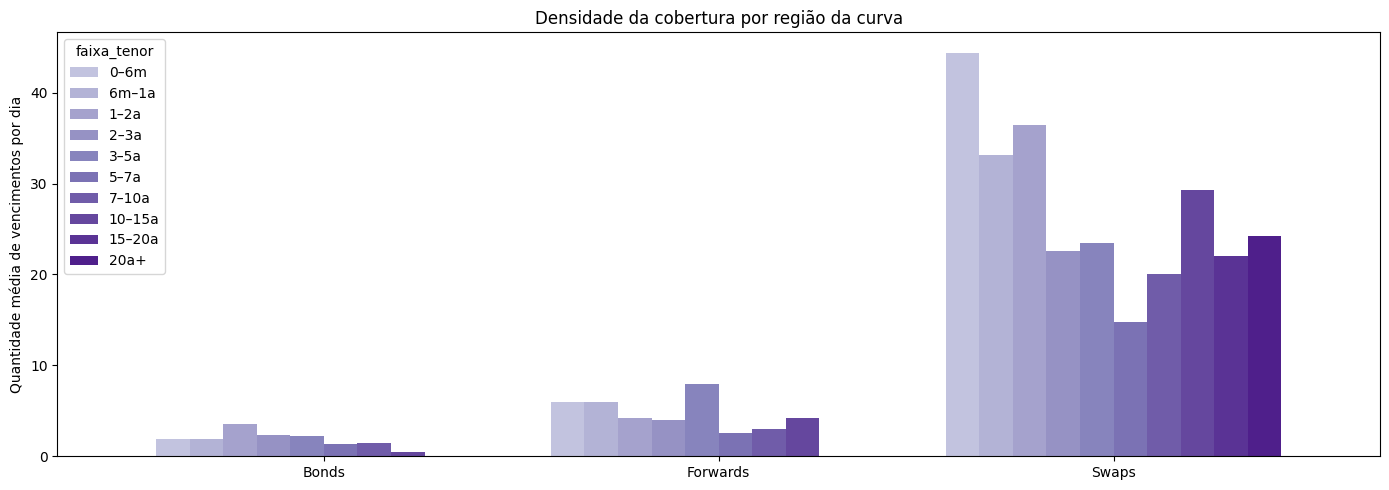

In [66]:
faixas = [0, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, float("inf")]
rotulos = ["0–6m", "6m–1a", "1–2a", "2–3a", "3–5a",
           "5–7a", "7–10a", "10–15a", "15–20a", "20a+"]

painel["faixa_tenor"] = pd.cut(
    painel["tenor_anos"],
    bins=faixas,
    labels=rotulos,
    right=False,
)

densidade = (
    painel.groupby(["mercado", "date", "faixa_tenor"], observed=False)
    .size()
    .groupby(["mercado", "faixa_tenor"], observed=False)
    .mean()
    .unstack(fill_value=0)
)

cores = plt.cm.Purples(
    np.linspace(0.35, 0.90, len(densidade.columns))
)

ax = densidade.plot.bar(
    figsize=(14, 5),
    width=0.85,
    color=cores,
)

ax.set_ylabel("Quantidade média de vencimentos por dia")
ax.set_xlabel("")
ax.set_title("Densidade da cobertura por região da curva")
plt.xticks(rotation=0)
plt.tight_layout()

### Distribuição por regiões da curva
O gráfico de ocupação por faixas de tenor indica uma distribuição relativamente equilibrada para títulos públicos e futuros, enquanto os swaps apresentam maior concentração nos segmentos de curto e médio prazo. Essa concentração sugere que a vantagem dos swaps não está apenas no número total de observações, mas também na maior granularidade em regiões relevantes para a formação das expectativas de juros, como esperado de um arquivo com taxas de referência.

Importante destacar que entre a base de futuros e de títulos, apesar dos dados da DEMAB cobrirem maior horizonte histórico contínuo a quantidade de dados por dia em média é 18 enquanto para a base de futuros temos 38 vencimentos em média, quase 3 vezes mais vértices, logo a base da DEMAB em uma análise transversal diária apresenta cenários mais subindentificados
